# Feature Extraction\nExtracts 76 features per cycle: MFCCs, Delta MFCCs, Mel Spectrogram means, ZCR, Centroid, Bandwidth, Rolloff, and RMS.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_classif

# Configuration
data_dir = r'C:\Users\Kruthi K Shetty\data-science\data'
npy_path = os.path.join(data_dir, 'processed_cycles.npy')
df_path = os.path.join(data_dir, 'cycles_df_processed.csv')
out_df_path = os.path.join(data_dir, 'features_df.csv')

SR = 22050

print("Loading data...")
X_audio = np.load(npy_path)
df = pd.read_csv(df_path)
print(f"Loaded audio shape: {X_audio.shape}")
print(f"Loaded DataFrame shape: {df.shape}")


Loading data...
Loaded audio shape: (6869, 66150)
Loaded DataFrame shape: (6869, 8)


In [2]:
# Initialize list to hold all features
all_features = []

total_clips = len(X_audio)
print(f"Starting feature extraction for {total_clips} clips...")

start_time = time.time()
batch_start_time = time.time()

for i, y in enumerate(X_audio):
    # Dictionary to hold features for this clip
    features = {}
    
    # 1. MFCC & Delta MFCC (13 + 13 = 26 features)
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfcc)
    
    for j in range(13):
        features[f'mfcc_{j+1}_mean'] = np.mean(mfcc[j])
        features[f'mfcc_delta_{j+1}_mean'] = np.mean(mfcc_delta[j])
        
    # 2. Mel Spectrogram (mean of 40 bands = 40 features)
    # Using 40 bands instead of 1 global mean ensures we capture frequency distribution
    mel_spec = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=40)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    for j in range(40):
        features[f'mel_band_{j+1}_mean'] = np.mean(mel_spec_db[j])
        
    # 3. Zero Crossing Rate (mean and std = 2 features)
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    # 4. Spectral Centroid (mean and std = 2 features)
    cent = librosa.feature.spectral_centroid(y=y, sr=SR)
    features['centroid_mean'] = np.mean(cent)
    features['centroid_std'] = np.std(cent)
    
    # 5. Spectral Bandwidth (mean and std = 2 features)
    bw = librosa.feature.spectral_bandwidth(y=y, sr=SR)
    features['bandwidth_mean'] = np.mean(bw)
    features['bandwidth_std'] = np.std(bw)
    
    # 6. Spectral Rolloff (mean and std = 2 features)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=SR)
    features['rolloff_mean'] = np.mean(rolloff)
    features['rolloff_std'] = np.std(rolloff)
    
    # 7. RMS Energy (mean and std = 2 features)
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    all_features.append(features)
    
    # Progress and timing
    if (i + 1) % 100 == 0:
        elapsed = time.time() - batch_start_time
        print(f"Processed {i + 1}/{total_clips} clips. Time for last 100: {elapsed:.2f}s")
        batch_start_time = time.time()

total_time = time.time() - start_time
print(f"\nExtraction complete! Total time: {total_time:.2f}s")


Starting feature extraction for 6869 clips...
Processed 100/6869 clips. Time for last 100: 23.58s
Processed 200/6869 clips. Time for last 100: 7.97s
Processed 300/6869 clips. Time for last 100: 10.70s
Processed 400/6869 clips. Time for last 100: 8.34s
Processed 500/6869 clips. Time for last 100: 9.18s
Processed 600/6869 clips. Time for last 100: 10.80s
Processed 700/6869 clips. Time for last 100: 7.70s
Processed 800/6869 clips. Time for last 100: 8.03s
Processed 900/6869 clips. Time for last 100: 7.66s
Processed 1000/6869 clips. Time for last 100: 8.33s
Processed 1100/6869 clips. Time for last 100: 7.53s
Processed 1200/6869 clips. Time for last 100: 7.73s
Processed 1300/6869 clips. Time for last 100: 7.64s
Processed 1400/6869 clips. Time for last 100: 7.82s
Processed 1500/6869 clips. Time for last 100: 7.47s
Processed 1600/6869 clips. Time for last 100: 7.70s
Processed 1700/6869 clips. Time for last 100: 7.36s
Processed 1800/6869 clips. Time for last 100: 7.51s
Processed 1900/6869 clip

In [3]:
# Create Features DataFrame
features_df = pd.DataFrame(all_features)
features_df['npy_index'] = np.arange(len(features_df))

print(f"Extracted features shape (without metadata): {features_df.shape}")

# Merge with metadata on npy_index
columns_to_keep = ['npy_index', 'patient_id', 'filename', 'cycle_start', 'cycle_end', 'label']
meta_df = df[columns_to_keep]

final_df = pd.merge(meta_df, features_df, on='npy_index', how='inner')

print(f"Final merged DataFrame shape: {final_df.shape}")

# Save to CSV
final_df.to_csv(out_df_path, index=False)
print(f"Saved feature dataset to {out_df_path}")

final_df.head()


Extracted features shape (without metadata): (6869, 77)
Final merged DataFrame shape: (6869, 82)
Saved feature dataset to C:\Users\Kruthi K Shetty\data-science\data\features_df.csv


,npy_index,patient_id,filename,cycle_start,cycle_end,label,mfcc_1_mean,mfcc_delta_1_mean,mfcc_2_mean,mfcc_delta_2_mean,...,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,rms_mean,rms_std
0,0,101,101_1b1_Al_sc_Meditron.txt,0.036,0.579,Normal,-516.077513,-1.691976,37.896544,-1.240744,...,0.003846,0.007576,162.818423,161.189802,131.732771,215.678398,247.631836,315.425102,0.017861,0.045098
1,1,101,101_1b1_Al_sc_Meditron.txt,0.579,2.450,Normal,-449.345028,-1.869504,111.281387,-1.256269,...,0.011411,0.009060,254.856122,168.214764,247.533509,229.157301,418.572341,340.317940,0.049490,0.063270
2,2,101,101_1b1_Al_sc_Meditron.txt,2.450,3.893,Normal,-470.643018,-1.539416,88.862601,-1.385398,...,0.009608,0.010217,231.325721,162.380182,223.173049,220.672522,391.738657,343.840524,0.039692,0.060669
3,3,101,101_1b1_Al_sc_Meditron.txt,3.893,5.793,Normal,-451.179377,-2.016558,103.704947,-1.322211,...,0.011080,0.008604,250.859120,161.533067,248.583076,228.245765,415.673640,335.561803,0.044501,0.059709
4,4,101,101_1b1_Al_sc_Meditron.txt,5.793,7.521,Normal,-461.284902,-1.672789,96.253710,-1.296174,...,0.009781,0.008391,233.449468,162.716414,230.795810,239.098807,380.806415,331.999759,0.041860,0.056816


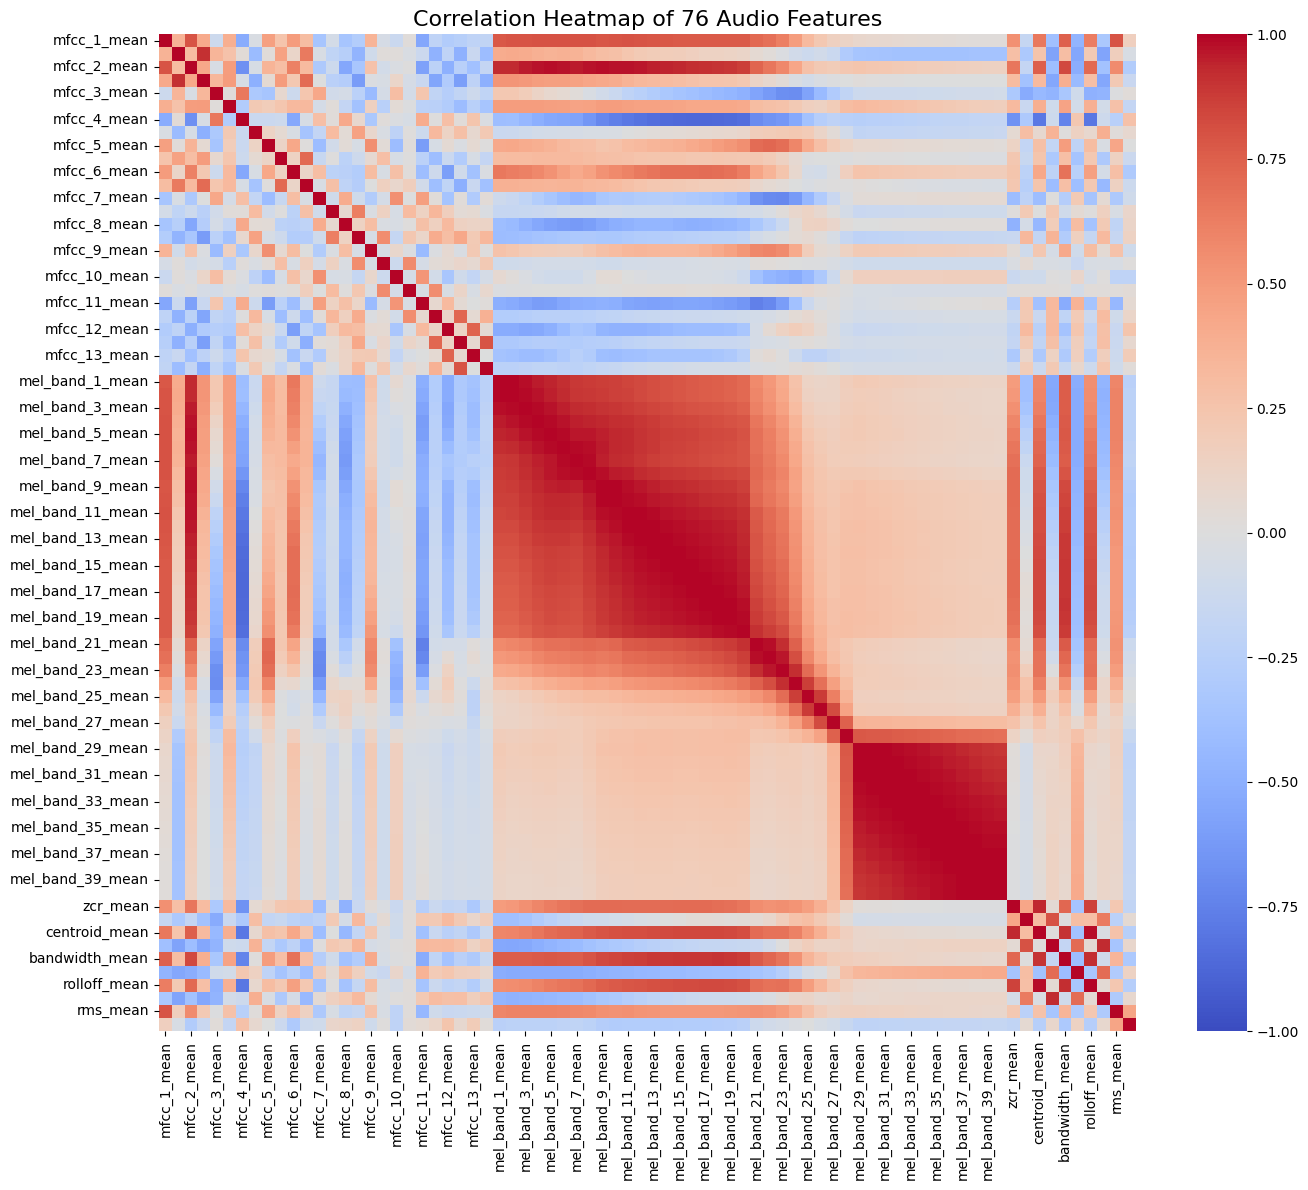

In [4]:
# Heatmap of correlation matrix
feature_cols = [c for c in final_df.columns if c not in columns_to_keep]

plt.figure(figsize=(14, 12))
corr_matrix = final_df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of 76 Audio Features', fontsize=16)
plt.tight_layout()
plt.show()


Top 5 most label-discriminating features (by ANOVA F-score):
rms_std         108.901379
mfcc_3_mean      99.641913
mfcc_11_mean     94.812496
mfcc_9_mean      68.432683
mfcc_6_mean      66.573588
dtype: float64


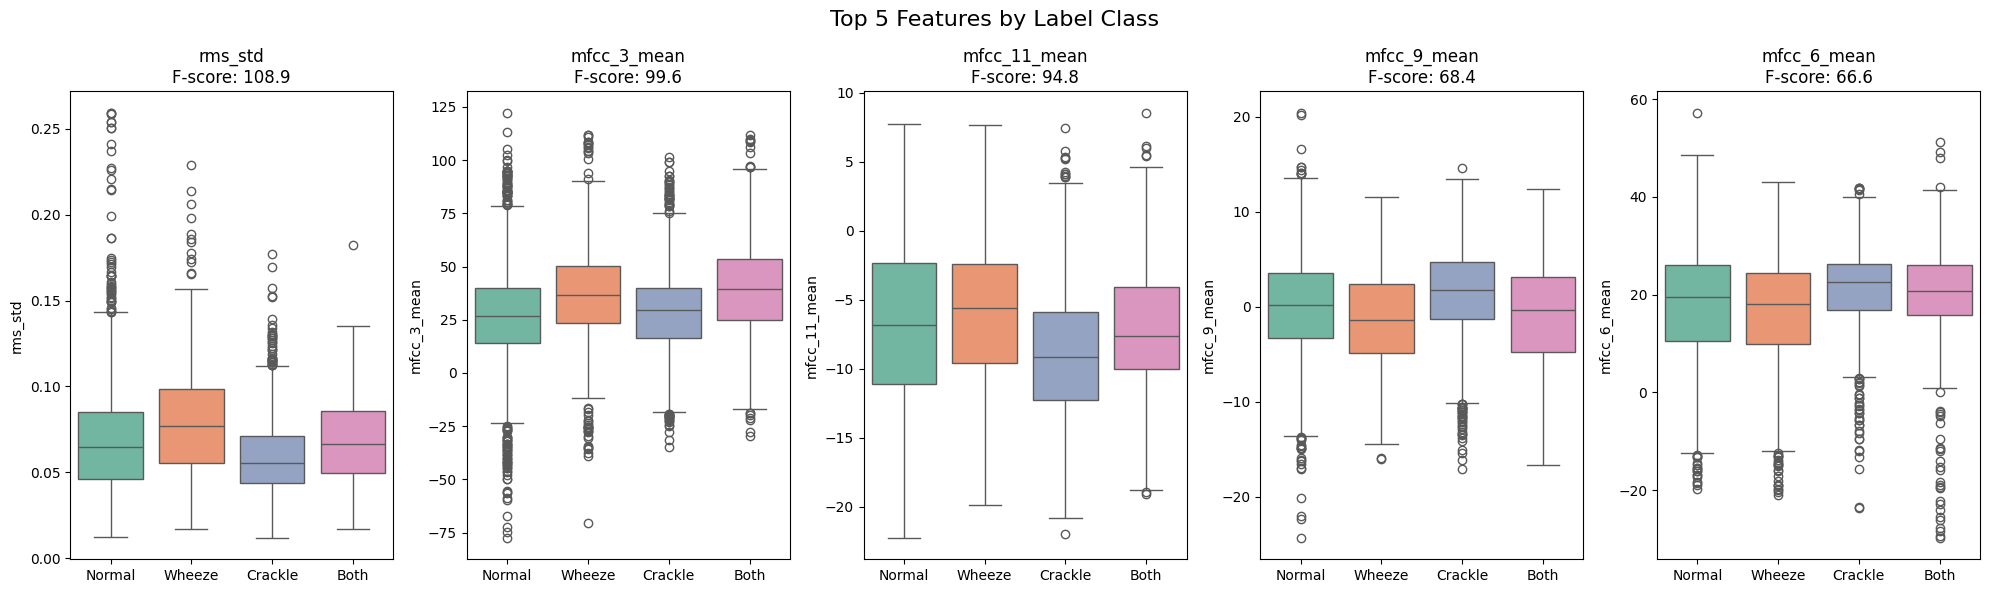

In [5]:
import warnings
warnings.filterwarnings('ignore') # Ignore some potential ANOVA division by zero warnings if any feature is perfectly constant

# Identify top 5 discriminating features using ANOVA F-value
X = final_df[feature_cols]
y_labels = final_df['label']

# Calculate F-scores
f_scores, p_values = f_classif(X, y_labels)

# Create a series with feature names and their F-scores
f_score_series = pd.Series(f_scores, index=feature_cols)
# Fill NaN with 0 in case of perfect constancy
f_score_series = f_score_series.fillna(0)
top_5_features = f_score_series.nlargest(5).index.tolist()

print(f"Top 5 most label-discriminating features (by ANOVA F-score):\n{f_score_series.nlargest(5)}")

# Plot boxplots for the top 5 features
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Top 5 Features by Label Class', fontsize=16)

for i, feature in enumerate(top_5_features):
    sns.boxplot(x='label', y=feature, data=final_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature}\nF-score: {f_score_series[feature]:.1f}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()
